In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv("sales_dataset_cleaned.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1000, 12)


,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Rows: 1000
Columns: 12

Column Names:
['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Age', 'Gender', 'City', 'Product', 'Category', 'Quantity', 'Unit_Price', 'Total_Sales']

Data Types:
Order_ID          object
Order_Date        object
Customer_ID       object
Customer_Name     object
Age              float64
Gender            object
City              object
Product           object
Category          object
Quantity           int64
Unit_Price       float64
Total_Sales      float64
dtype: object

Missing Values:
Order_ID         0
Order_Date       0
Customer_ID      0
Customer_Name    0
Age              0
Gender           0
City             0
Product          0
Category         0
Quantity         0
Unit_Price       0
Total_Sales      0
dtype: int64


In [5]:
df.describe()

,Age,Quantity,Unit_Price,Total_Sales
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,41.353000,5.435000,25486.783410,139399.439650
std,13.683626,2.838632,14179.402361,114100.051546
min,18.000000,1.000000,145.780000,437.340000
25%,30.000000,3.000000,13895.722500,47066.632500
50%,41.000000,5.000000,25398.740000,108594.025000
75%,53.000000,8.000000,37512.382500,203722.882500
max,65.000000,10.000000,49997.530000,493677.500000


In [8]:
print(df['Product'].value_counts())

Product
Mobile    184
Book      178
Laptop    170
Chair     159
Shoes     156
Rice      153
Name: count, dtype: int64


In [10]:
print(df['Category'].value_counts())

Category
Electronics    354
Education      178
Furniture      159
Fashion        156
Grocery        153
Name: count, dtype: int64


In [11]:
print(df['City'].value_counts())

City
Patna        148
Kolkata      133
Mumbai       131
Hyderabad    125
Delhi        125
Bengaluru    122
Gaya         117
Pune          99
Name: count, dtype: int64


In [12]:
print(df['Gender'].value_counts())

Gender
Male      511
Female    489
Name: count, dtype: int64


In [17]:
product_sales=df.groupby('Product')['Total_Sales'].sum().sort_values(ascending=False)
print(product_sales)

Product
Laptop    25443008.51
Mobile    25335573.19
Book      25031689.40
Rice      22231711.28
Chair     21521561.48
Shoes     19835895.79
Name: Total_Sales, dtype: float64


In [18]:
category_sales=df.groupby('Category')['Total_Sales'].sum().sort_values(ascending=False)
print(category_sales)

Category
Electronics    50778581.70
Education      25031689.40
Grocery        22231711.28
Furniture      21521561.48
Fashion        19835895.79
Name: Total_Sales, dtype: float64


In [19]:
city_sales=df.groupby('City')['Total_Sales'].sum().sort_values(ascending=False)
print(city_sales)

City
Patna        20826584.43
Kolkata      18884349.57
Bengaluru    18773574.32
Mumbai       18757050.17
Hyderabad    17166766.87
Delhi        16097079.00
Pune         14513175.90
Gaya         14380859.39
Name: Total_Sales, dtype: float64


In [20]:
import pandas as pd
import sqlite3

df = pd.read_csv("sales_dataset_cleaned.csv")

conn = sqlite3.connect("apexplanet_task2.db")

df.to_sql("sales", conn, if_exists="replace", index=False)

print("Dataset loaded into SQL successfully!")

Dataset loaded into SQL successfully!


In [21]:
result = pd.read_sql_query(
    "SELECT COUNT(*) AS total_rows FROM sales",
    conn
)

print(result)

   total_rows
0        1000


In [22]:
query1 = """
SELECT
    Product,
    SUM(Total_Sales) AS Total_Sales
FROM sales
GROUP BY Product
ORDER BY Total_Sales DESC;
"""

result1 = pd.read_sql_query(query1, conn)

print(result1)

  Product  Total_Sales
0  Laptop  25443008.51
1  Mobile  25335573.19
2    Book  25031689.40
3    Rice  22231711.28
4   Chair  21521561.48
5   Shoes  19835895.79


In [23]:
query2 = """
SELECT
    Category,
    SUM(Total_Sales) AS Total_Sales
FROM sales
GROUP BY Category
ORDER BY Total_Sales DESC;
"""

result2 = pd.read_sql_query(query2, conn)

print(result2)

      Category  Total_Sales
0  Electronics  50778581.70
1    Education  25031689.40
2      Grocery  22231711.28
3    Furniture  21521561.48
4      Fashion  19835895.79


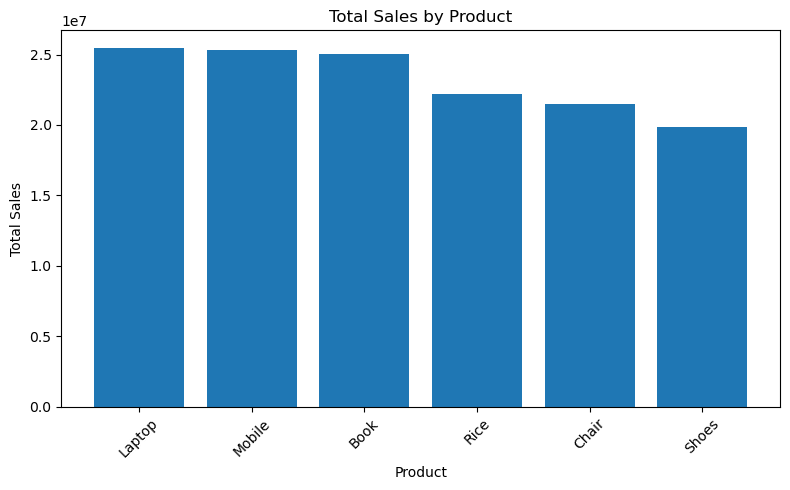

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(result1['Product'], result1['Total_Sales'])

plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.title("Total Sales by Product")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
query2 = """
SELECT
    Category,
    SUM(Total_Sales) AS Total_Sales
FROM sales
GROUP BY Category
ORDER BY Total_Sales DESC;
"""

result2 = pd.read_sql_query(query2, conn)

print(result2)

      Category  Total_Sales
0  Electronics  50778581.70
1    Education  25031689.40
2      Grocery  22231711.28
3    Furniture  21521561.48
4      Fashion  19835895.79


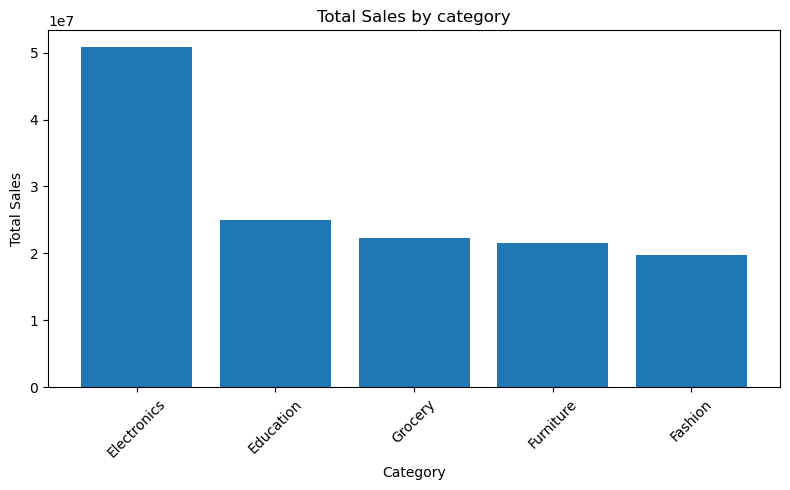

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(result2['Category'], result2['Total_Sales'])

plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.title("Total Sales by category")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
query3 = """
SELECT
    City,
    SUM(Total_Sales) AS Total_Sales
FROM sales
GROUP BY City
ORDER BY Total_Sales DESC;
"""

result3 = pd.read_sql_query(query3, conn)

print(result3)

        City  Total_Sales
0      Patna  20826584.43
1    Kolkata  18884349.57
2  Bengaluru  18773574.32
3     Mumbai  18757050.17
4  Hyderabad  17166766.87
5      Delhi  16097079.00
6       Pune  14513175.90
7       Gaya  14380859.39


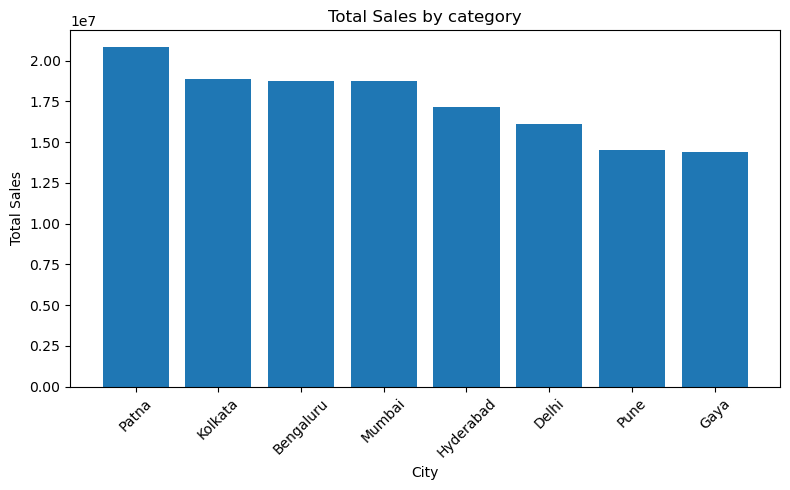

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(result3['City'], result3['Total_Sales'])
plt.xlabel("City")
plt.ylabel("Total Sales")
plt.title("Total Sales by category")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [33]:
query4 = """
SELECT
    Category,
    AVG(Total_Sales) AS Average_Order_Value
FROM sales
GROUP BY Category
ORDER BY Average_Order_Value DESC;
"""

result4 = pd.read_sql_query(query4, conn)

print(result4)

      Category  Average_Order_Value
0      Grocery        145305.302484
1  Electronics        143442.321186
2    Education        140627.468539
3    Furniture        135355.732579
4      Fashion        127153.178141


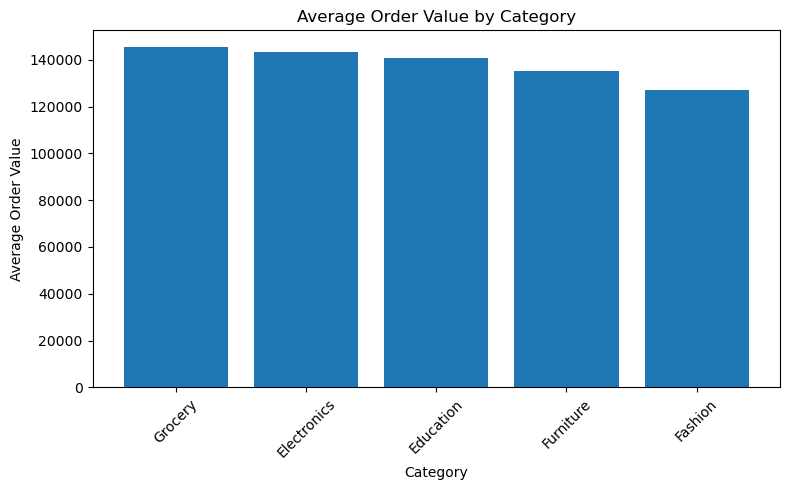

In [34]:
plt.figure(figsize=(8, 5))

plt.bar(result4['Category'], result4['Average_Order_Value'])

plt.xlabel("Category")
plt.ylabel("Average Order Value")
plt.title("Average Order Value by Category")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [35]:
query5 = """
SELECT
    Product,
    AVG(Quantity) AS Average_Quantity
FROM sales
GROUP BY Product
ORDER BY Average_Quantity DESC;
"""

result5 = pd.read_sql_query(query5, conn)

print(result5)

  Product  Average_Quantity
0  Laptop          5.705882
1    Book          5.488764
2  Mobile          5.478261
3    Rice          5.398693
4   Chair          5.377358
5   Shoes          5.121795


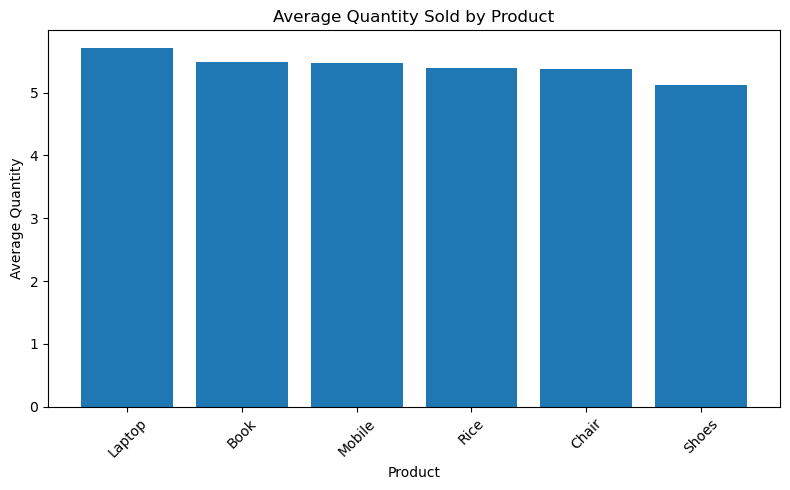

In [36]:
plt.figure(figsize=(8, 5))

plt.bar(result5['Product'], result5['Average_Quantity'])

plt.xlabel("Product")
plt.ylabel("Average Quantity")
plt.title("Average Quantity Sold by Product")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [38]:
query6 = """
SELECT
    Gender,
    SUM(Total_Sales) AS Total_Sales
FROM sales
GROUP BY Gender
ORDER BY Total_Sales DESC;
"""

result6 = pd.read_sql_query(query6, conn)

print(result6)

   Gender  Total_Sales
0    Male  72463550.63
1  Female  66935889.02


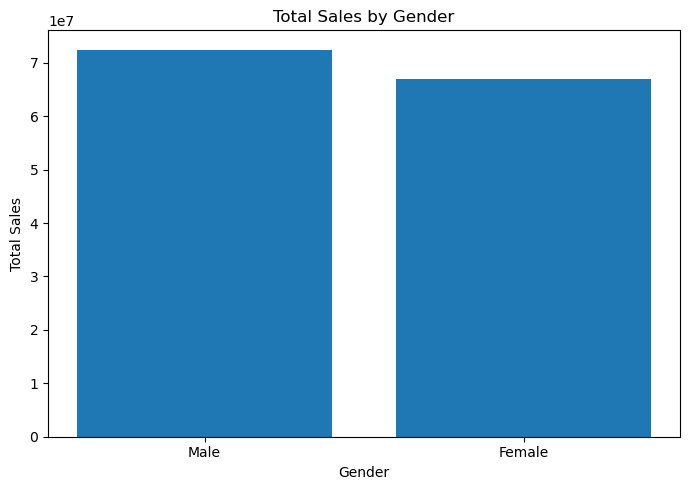

In [39]:
plt.figure(figsize=(7, 5))

plt.bar(result6['Gender'], result6['Total_Sales'])

plt.xlabel("Gender")
plt.ylabel("Total Sales")
plt.title("Total Sales by Gender")

plt.tight_layout()
plt.show()

In [40]:
query7 = """
SELECT
    strftime('%Y-%m', Order_Date) AS Month,
    SUM(Total_Sales) AS Total_Sales
FROM sales
GROUP BY Month
ORDER BY Month;
"""

result7 = pd.read_sql_query(query7, conn)

print(result7)

      Month  Total_Sales
0   2025-01  10096190.73
1   2025-02  11511181.46
2   2025-03  13059899.94
3   2025-04  12222700.17
4   2025-05  10984689.25
5   2025-06  12912332.64
6   2025-07  11746226.80
7   2025-08   9448471.22
8   2025-09   9179896.29
9   2025-10  12500936.50
10  2025-11  12627620.22
11  2025-12  12299904.44
12  2026-01    809389.99


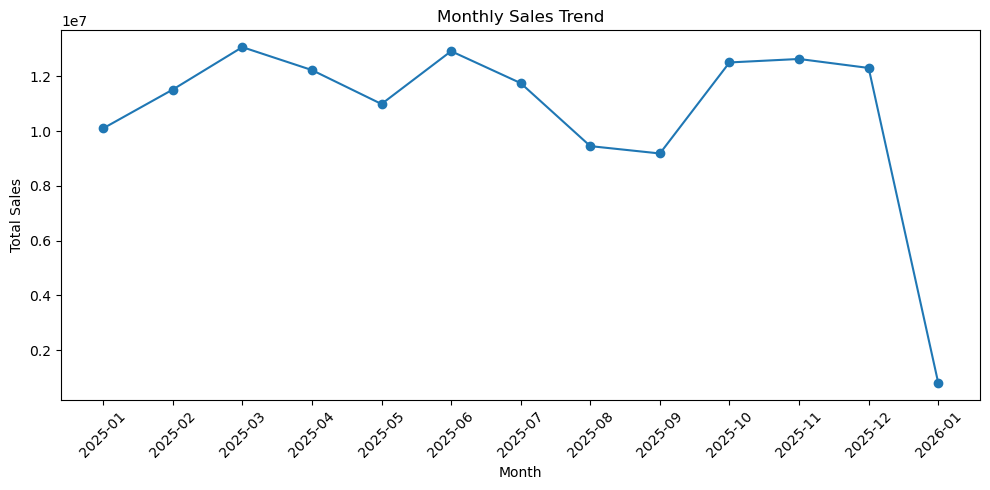

In [41]:
plt.figure(figsize=(10, 5))

plt.plot(result7['Month'], result7['Total_Sales'], marker='o')

plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales Trend")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
import pandas as pd

df = pd.read_csv("sales_dataset_cleaned.csv")

print(df.shape)

(1000, 12)


In [6]:
numeric_cols = ['Age', 'Quantity', 'Unit_Price', 'Total_Sales']

correlation = df[numeric_cols].corr()

print(correlation)

                  Age  Quantity  Unit_Price  Total_Sales
Age          1.000000 -0.027666   -0.011955     0.001294
Quantity    -0.027666  1.000000    0.021855     0.646641
Unit_Price  -0.011955  0.021855    1.000000     0.686303
Total_Sales  0.001294  0.646641    0.686303     1.000000


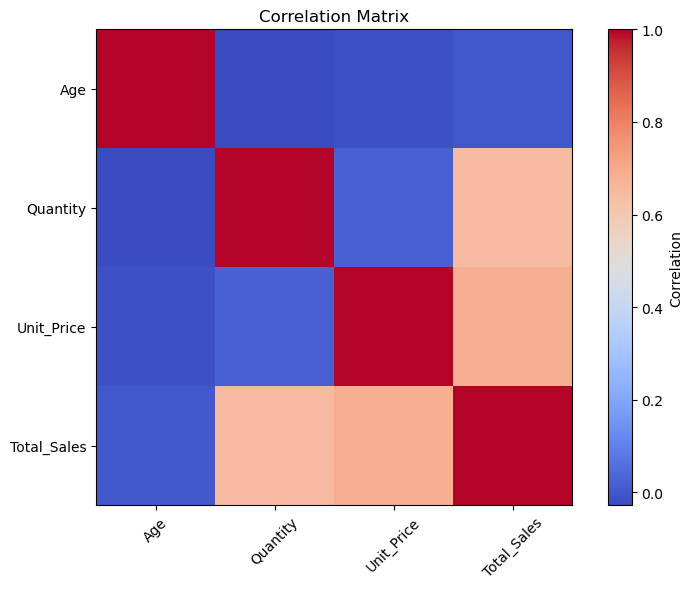

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.imshow(correlation, cmap='coolwarm', interpolation='nearest')

plt.colorbar(label='Correlation')

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

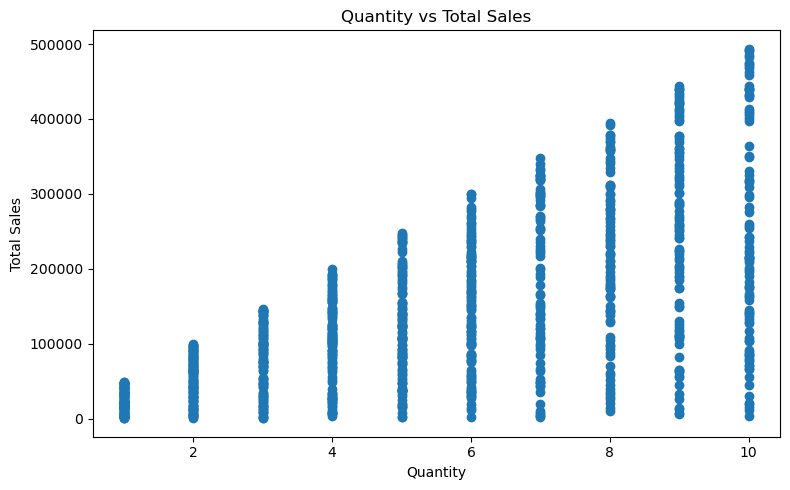

In [8]:
# -----------------------------------------
# STEP 8.3: QUANTITY vs TOTAL SALES
# -----------------------------------------
# A scatter plot helps us visually understand
# the relationship between two numerical variables.
#
# X-axis  -> Quantity purchased
# Y-axis  -> Total Sales
#
# We expect Total Sales to generally increase
# as Quantity increases.

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Create one point for each transaction
plt.scatter(
    df['Quantity'],
    df['Total_Sales']
)

# Add meaningful labels and title
plt.xlabel("Quantity")
plt.ylabel("Total Sales")
plt.title("Quantity vs Total Sales")

# Display the chart
plt.tight_layout()
plt.show()

In [9]:
# -----------------------------------------
# STEP 9.1: CALCULATE DASHBOARD KPIs
# -----------------------------------------
# KPIs (Key Performance Indicators) are
# important summary numbers used to understand
# overall business performance.
#
# We will calculate:
# 1. Total Sales
# 2. Number of Transactions
# 3. Average Quantity per Transaction
# 4. Average Order Value

# Total revenue/sales generated
total_sales = df['Total_Sales'].sum()

# Number of transaction records
total_transactions = len(df)

# Average number of units purchased per transaction
average_quantity = df['Quantity'].mean()

# Average value of one transaction
average_order_value = df['Total_Sales'].mean()

# Display the KPI values
print("Total Sales:", total_sales)
print("Total Transactions:", total_transactions)
print("Average Quantity:", average_quantity)
print("Average Order Value:", average_order_value)

Total Sales: 139399439.65
Total Transactions: 1000
Average Quantity: 5.435
Average Order Value: 139399.43965000001


In [11]:
# -----------------------------------------
# FIX: CONVERT ORDER_DATE TO DATETIME
# -----------------------------------------
# When we read a CSV file, date columns are
# usually loaded as text (object).
#
# Pandas' .dt accessor works only with actual
# datetime values, so we convert Order_Date
# before performing month-based analysis.

df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Check the data type after conversion
print("Order_Date data type:", df['Order_Date'].dtype)


Order_Date data type: datetime64[ns]


In [12]:
# -----------------------------------------
# STEP 9.2: PREPARE DASHBOARD DATA
# -----------------------------------------

# 1. Sales by Product
sales_by_product = (
    df.groupby('Product')['Total_Sales']
      .sum()
      .sort_values(ascending=False)
)

# 2. Sales by Category
sales_by_category = (
    df.groupby('Category')['Total_Sales']
      .sum()
      .sort_values(ascending=False)
)

# 3. Sales by City
sales_by_city = (
    df.groupby('City')['Total_Sales']
      .sum()
      .sort_values(ascending=False)
)

# 4. Monthly Sales Trend
# Convert each date into a Year-Month period
# and calculate total sales for each month.
monthly_sales = (
    df.groupby(df['Order_Date'].dt.to_period('M'))['Total_Sales']
      .sum()
)

# Convert the month index to text for easier plotting
monthly_sales.index = monthly_sales.index.astype(str)

# Display the prepared summary tables
print("Sales by Product:")
print(sales_by_product)

print("\nSales by Category:")
print(sales_by_category)

print("\nSales by City:")
print(sales_by_city)

print("\nMonthly Sales:")
print(monthly_sales)

Sales by Product:
Product
Laptop    25443008.51
Mobile    25335573.19
Book      25031689.40
Rice      22231711.28
Chair     21521561.48
Shoes     19835895.79
Name: Total_Sales, dtype: float64

Sales by Category:
Category
Electronics    50778581.70
Education      25031689.40
Grocery        22231711.28
Furniture      21521561.48
Fashion        19835895.79
Name: Total_Sales, dtype: float64

Sales by City:
City
Patna        20826584.43
Kolkata      18884349.57
Bengaluru    18773574.32
Mumbai       18757050.17
Hyderabad    17166766.87
Delhi        16097079.00
Pune         14513175.90
Gaya         14380859.39
Name: Total_Sales, dtype: float64

Monthly Sales:
Order_Date
2025-01    10096190.73
2025-02    11511181.46
2025-03    13059899.94
2025-04    12222700.17
2025-05    10984689.25
2025-06    12912332.64
2025-07    11746226.80
2025-08     9448471.22
2025-09     9179896.29
2025-10    12500936.50
2025-11    12627620.22
2025-12    12299904.44
2026-01      809389.99
Name: Total_Sales, dtype: flo

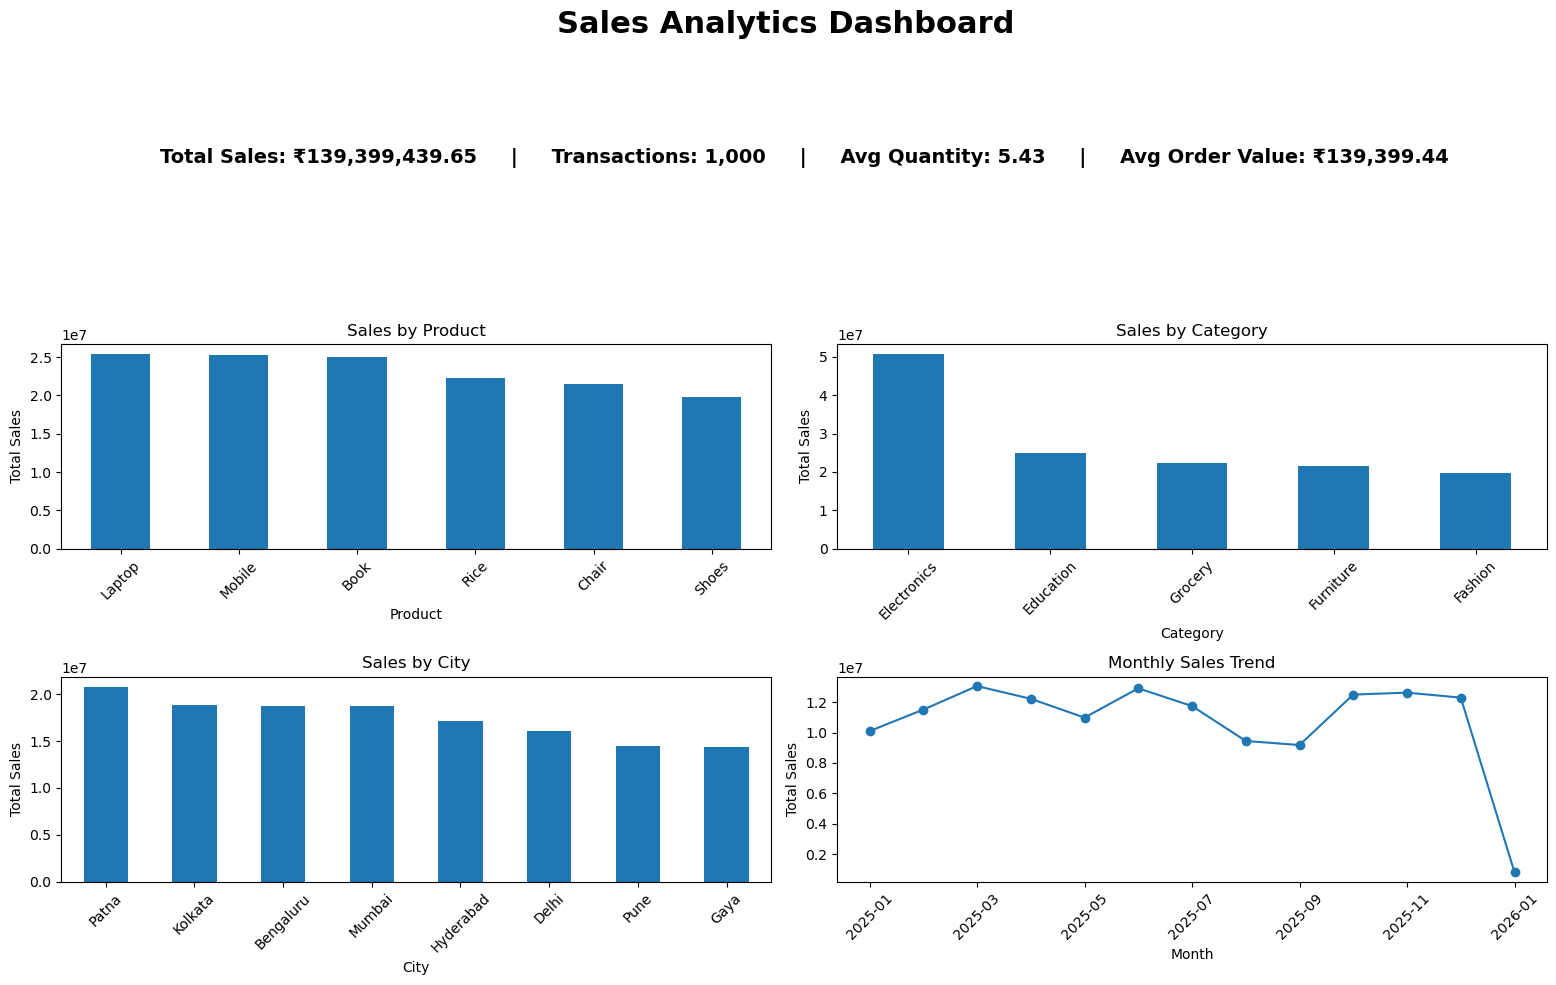

Dashboard created successfully!
Saved as: task2_dashboard.png


In [13]:
# -----------------------------------------
# STEP 9.3: CREATE STATIC DASHBOARD
# -----------------------------------------
# This code combines our KPIs and analysis
# results into one dashboard-style figure.
#
# The dashboard contains:
#   1. KPI summary
#   2. Sales by Product
#   3. Sales by Category
#   4. Sales by City
#   5. Monthly Sales Trend
#
# The final dashboard will be saved as an
# image that can be uploaded to GitHub.

import matplotlib.pyplot as plt

# -----------------------------------------
# CREATE DASHBOARD CANVAS
# -----------------------------------------
# figsize controls the overall dashboard size.

fig = plt.figure(figsize=(16, 10))

# Create a 3x2 grid of sections.
# The first row will contain our KPI information.
# The remaining sections will contain charts.

gs = fig.add_gridspec(
    3,
    2,
    height_ratios=[0.8, 1.4, 1.4]
)

# -----------------------------------------
# DASHBOARD TITLE
# -----------------------------------------

fig.suptitle(
    "Sales Analytics Dashboard",
    fontsize=22,
    fontweight='bold'
)

# -----------------------------------------
# KPI SECTION
# -----------------------------------------
# Display the four important business KPIs.

kpi_ax = fig.add_subplot(gs[0, :])
kpi_ax.axis('off')

kpi_text = (
    f"Total Sales: ₹{total_sales:,.2f}     |     "
    f"Transactions: {total_transactions:,}     |     "
    f"Avg Quantity: {average_quantity:.2f}     |     "
    f"Avg Order Value: ₹{average_order_value:,.2f}"
)

kpi_ax.text(
    0.5,
    0.5,
    kpi_text,
    ha='center',
    va='center',
    fontsize=14,
    fontweight='bold'
)

# -----------------------------------------
# CHART 1: SALES BY PRODUCT
# -----------------------------------------

ax1 = fig.add_subplot(gs[1, 0])

sales_by_product.plot(
    kind='bar',
    ax=ax1
)

ax1.set_title("Sales by Product")
ax1.set_xlabel("Product")
ax1.set_ylabel("Total Sales")
ax1.tick_params(axis='x', rotation=45)

# -----------------------------------------
# CHART 2: SALES BY CATEGORY
# -----------------------------------------

ax2 = fig.add_subplot(gs[1, 1])

sales_by_category.plot(
    kind='bar',
    ax=ax2
)

ax2.set_title("Sales by Category")
ax2.set_xlabel("Category")
ax2.set_ylabel("Total Sales")
ax2.tick_params(axis='x', rotation=45)

# -----------------------------------------
# CHART 3: SALES BY CITY
# -----------------------------------------

ax3 = fig.add_subplot(gs[2, 0])

sales_by_city.plot(
    kind='bar',
    ax=ax3
)

ax3.set_title("Sales by City")
ax3.set_xlabel("City")
ax3.set_ylabel("Total Sales")
ax3.tick_params(axis='x', rotation=45)

# -----------------------------------------
# CHART 4: MONTHLY SALES TREND
# -----------------------------------------

ax4 = fig.add_subplot(gs[2, 1])

monthly_sales.plot(
    kind='line',
    marker='o',
    ax=ax4
)

ax4.set_title("Monthly Sales Trend")
ax4.set_xlabel("Month")
ax4.set_ylabel("Total Sales")
ax4.tick_params(axis='x', rotation=45)

# -----------------------------------------
# FINAL DASHBOARD FORMATTING
# -----------------------------------------

plt.tight_layout(rect=[0, 0, 1, 0.95])

# -----------------------------------------
# SAVE DASHBOARD
# -----------------------------------------
# Saving the dashboard as PNG allows us to
# upload it to GitHub and include it in our
# EDA report.

plt.savefig(
    "task2_dashboard.png",
    dpi=300,
    bbox_inches='tight'
)

# Display the dashboard in Jupyter
plt.show()

print("Dashboard created successfully!")
print("Saved as: task2_dashboard.png")

In [1]:
# =========================================================
# TASK 2 - STEP 10.1: RECREATE AND SAVE SQL RESULTS
# =========================================================
# Our Jupyter kernel was restarted, so the previous variables
# result1, result2, ..., result7 are no longer available.
#
# This cell rebuilds the SQL analysis from the cleaned dataset
# and saves all seven business-question results into one Excel
# workbook.
# =========================================================

# -----------------------------------------
# 1. IMPORT REQUIRED LIBRARIES
# -----------------------------------------

import pandas as pd
import sqlite3

# -----------------------------------------
# 2. LOAD THE CLEANED DATASET
# -----------------------------------------
# The cleaned CSV contains the analysis-ready
# sales transaction data from Task 1.

df = pd.read_csv("sales_dataset_cleaned.csv")

# Convert Order_Date from text into datetime format.
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

# -----------------------------------------
# 3. CREATE SQLITE DATABASE CONNECTION
# -----------------------------------------
# SQLite allows us to run SQL queries directly
# from this Jupyter notebook.

conn = sqlite3.connect("apexplanet_task2.db")

# Load the DataFrame into a SQL table named 'sales'.
df.to_sql(
    "sales",
    conn,
    if_exists="replace",
    index=False
)

print("Sales table created successfully!")

# =========================================================
# 4. BUSINESS QUESTION 1
# =========================================================
# Which products generate the highest total sales?

query1 = """
SELECT
    Product,
    SUM(Total_Sales) AS Total_Sales
FROM sales
GROUP BY Product
ORDER BY Total_Sales DESC;
"""

result1 = pd.read_sql_query(query1, conn)

# =========================================================
# 5. BUSINESS QUESTION 2
# =========================================================
# Which categories generate the highest total sales?

query2 = """
SELECT
    Category,
    SUM(Total_Sales) AS Total_Sales
FROM sales
GROUP BY Category
ORDER BY Total_Sales DESC;
"""

result2 = pd.read_sql_query(query2, conn)

# =========================================================
# 6. BUSINESS QUESTION 3
# =========================================================
# Which cities generate the highest total sales?

query3 = """
SELECT
    City,
    SUM(Total_Sales) AS Total_Sales
FROM sales
GROUP BY City
ORDER BY Total_Sales DESC;
"""

result3 = pd.read_sql_query(query3, conn)

# =========================================================
# 7. BUSINESS QUESTION 4
# =========================================================
# Which categories have the highest average order value?

query4 = """
SELECT
    Category,
    AVG(Total_Sales) AS Average_Order_Value
FROM sales
GROUP BY Category
ORDER BY Average_Order_Value DESC;
"""

result4 = pd.read_sql_query(query4, conn)

# =========================================================
# 8. BUSINESS QUESTION 5
# =========================================================
# Which products have the highest average quantity sold?

query5 = """
SELECT
    Product,
    AVG(Quantity) AS Average_Quantity
FROM sales
GROUP BY Product
ORDER BY Average_Quantity DESC;
"""

result5 = pd.read_sql_query(query5, conn)

# =========================================================
# 9. BUSINESS QUESTION 6
# =========================================================
# How do total sales differ by gender?

query6 = """
SELECT
    Gender,
    SUM(Total_Sales) AS Total_Sales
FROM sales
GROUP BY Gender
ORDER BY Total_Sales DESC;
"""

result6 = pd.read_sql_query(query6, conn)

# =========================================================
# 10. BUSINESS QUESTION 7
# =========================================================
# How do sales change month by month?

query7 = """
SELECT
    strftime('%Y-%m', Order_Date) AS Month,
    SUM(Total_Sales) AS Total_Sales
FROM sales
GROUP BY Month
ORDER BY Month;
"""

result7 = pd.read_sql_query(query7, conn)

# =========================================================
# 11. SAVE ALL RESULTS TO EXCEL
# =========================================================
# Each business question gets its own worksheet.
# This creates a permanent record of our SQL analysis.

with pd.ExcelWriter("SQL_Results.xlsx") as writer:

    result1.to_excel(
        writer,
        sheet_name="Q1_Product_Sales",
        index=False
    )

    result2.to_excel(
        writer,
        sheet_name="Q2_Category_Sales",
        index=False
    )

    result3.to_excel(
        writer,
        sheet_name="Q3_City_Sales",
        index=False
    )

    result4.to_excel(
        writer,
        sheet_name="Q4_Avg_Order_Value",
        index=False
    )

    result5.to_excel(
        writer,
        sheet_name="Q5_Avg_Quantity",
        index=False
    )

    result6.to_excel(
        writer,
        sheet_name="Q6_Gender_Sales",
        index=False
    )

    result7.to_excel(
        writer,
        sheet_name="Q7_Monthly_Sales",
        index=False
    )

# -----------------------------------------
# 12. FINAL CONFIRMATION
# -----------------------------------------

print("\nSQL analysis completed successfully!")
print("All 7 business-question results were saved.")
print("File created: SQL_Results.xlsx")

Dataset loaded successfully!
Dataset shape: (1000, 12)
Sales table created successfully!

SQL analysis completed successfully!
All 7 business-question results were saved.
File created: SQL_Results.xlsx


In [3]:
# =========================================================
# TASK 2 - STEP 10.1: SAVE SQL QUERIES
# =========================================================
# This file stores all seven SQL queries used to answer
# the business questions in Task 2.
#
# Keeping the queries in a separate .sql file makes our
# project easier to understand and reproduce later.
# =========================================================

sql_queries = """

-- =====================================================
-- Q1: Which products generate the highest total sales?
-- =====================================================

SELECT
    Product,
    SUM(Total_Sales) AS Total_Sales
FROM sales
GROUP BY Product
ORDER BY Total_Sales DESC;


-- =====================================================
-- Q2: Which categories generate the highest total sales?
-- =====================================================

SELECT
    Category,
    SUM(Total_Sales) AS Total_Sales
FROM sales
GROUP BY Category
ORDER BY Total_Sales DESC;


-- =====================================================
-- Q3: Which cities generate the highest total sales?
-- =====================================================

SELECT
    City,
    SUM(Total_Sales) AS Total_Sales
FROM sales
GROUP BY City
ORDER BY Total_Sales DESC;


-- =====================================================
-- Q4: What is the average order value by category?
-- =====================================================

SELECT
    Category,
    AVG(Total_Sales) AS Average_Order_Value
FROM sales
GROUP BY Category
ORDER BY Average_Order_Value DESC;


-- =====================================================
-- Q5: Which products have the highest average quantity sold?
-- =====================================================

SELECT
    Product,
    AVG(Quantity) AS Average_Quantity
FROM sales
GROUP BY Product
ORDER BY Average_Quantity DESC;


-- =====================================================
-- Q6: What are the total sales by gender?
-- =====================================================

SELECT
    Gender,
    SUM(Total_Sales) AS Total_Sales
FROM sales
GROUP BY Gender
ORDER BY Total_Sales DESC;


-- =====================================================
-- Q7: How do sales change month by month?
-- =====================================================

SELECT
    strftime('%Y-%m', Order_Date) AS Month,
    SUM(Total_Sales) AS Total_Sales
FROM sales
GROUP BY Month
ORDER BY Month;

"""

# Save all SQL queries into a .sql file
with open("SQL_Queries.sql", "w", encoding="utf-8") as file:
    file.write(sql_queries)

print("SQL query file created successfully!")
print("File: SQL_Queries.sql")

SQL query file created successfully!
File: SQL_Queries.sql


In [4]:
# =========================================================
# TASK 2 - STEP 10.2: GENERATE EDA REPORT CONTENT
# =========================================================
# This cell creates the main content for our EDA report.
# It uses the actual cleaned dataset and calculates
# descriptive statistics and key analysis values.
# =========================================================

import pandas as pd

# Load the cleaned dataset
df = pd.read_csv("sales_dataset_cleaned.csv")

# Convert Order_Date from text to datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# ---------------------------------------------------------
# 1. Basic dataset information
# ---------------------------------------------------------

total_rows = len(df)
total_columns = len(df.columns)

total_sales = df['Total_Sales'].sum()
average_sales = df['Total_Sales'].mean()
average_quantity = df['Quantity'].mean()

# ---------------------------------------------------------
# 2. Descriptive statistics
# ---------------------------------------------------------

print("========== DATASET OVERVIEW ==========")
print("Rows:", total_rows)
print("Columns:", total_columns)

print("\n========== DESCRIPTIVE STATISTICS ==========")
print(df[['Age', 'Quantity', 'Unit_Price', 'Total_Sales']].describe())

# ---------------------------------------------------------
# 3. Product analysis
# ---------------------------------------------------------

product_sales = (
    df.groupby('Product')['Total_Sales']
      .sum()
      .sort_values(ascending=False)
)

print("\n========== SALES BY PRODUCT ==========")
print(product_sales)

# ---------------------------------------------------------
# 4. Category analysis
# ---------------------------------------------------------

category_sales = (
    df.groupby('Category')['Total_Sales']
      .sum()
      .sort_values(ascending=False)
)

print("\n========== SALES BY CATEGORY ==========")
print(category_sales)

# ---------------------------------------------------------
# 5. City analysis
# ---------------------------------------------------------

city_sales = (
    df.groupby('City')['Total_Sales']
      .sum()
      .sort_values(ascending=False)
)

print("\n========== SALES BY CITY ==========")
print(city_sales)

# ---------------------------------------------------------
# 6. Gender analysis
# ---------------------------------------------------------

gender_sales = (
    df.groupby('Gender')['Total_Sales']
      .sum()
      .sort_values(ascending=False)
)

print("\n========== SALES BY GENDER ==========")
print(gender_sales)

# ---------------------------------------------------------
# 7. Correlation analysis
# ---------------------------------------------------------

numeric_cols = [
    'Age',
    'Quantity',
    'Unit_Price',
    'Total_Sales'
]

correlation = df[numeric_cols].corr()

print("\n========== CORRELATION MATRIX ==========")
print(correlation)

# ---------------------------------------------------------
# 8. Display important summary values
# ---------------------------------------------------------

print("\n========== KEY METRICS ==========")
print(f"Total Sales: ₹{total_sales:,.2f}")
print(f"Average Order Value: ₹{average_sales:,.2f}")
print(f"Average Quantity: {average_quantity:.2f}")
print(f"Total Transactions: {total_rows:,}")

print("\nEDA report data prepared successfully!")

========== DATASET OVERVIEW ==========
Rows: 1000
Columns: 12

========== DESCRIPTIVE STATISTICS ==========
               Age     Quantity    Unit_Price    Total_Sales
count  1000.000000  1000.000000   1000.000000    1000.000000
mean     41.353000     5.435000  25486.783410  139399.439650
std      13.683626     2.838632  14179.402361  114100.051546
min      18.000000     1.000000    145.780000     437.340000
25%      30.000000     3.000000  13895.722500   47066.632500
50%      41.000000     5.000000  25398.740000  108594.025000
75%      53.000000     8.000000  37512.382500  203722.882500
max      65.000000    10.000000  49997.530000  493677.500000

========== SALES BY PRODUCT ==========
Product
Laptop    25443008.51
Mobile    25335573.19
Book      25031689.40
Rice      22231711.28
Chair     21521561.48
Shoes     19835895.79
Name: Total_Sales, dtype: float64

========== SALES BY CATEGORY ==========
Category
Electronics    50778581.70
Education      25031689.40
Grocery        22231711.2

In [6]:
# Install the python-docx library
# This library allows Python to create and edit Word documents.

%pip install python-docx

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [7]:
# Verify that python-docx is installed correctly

from docx import Document

print("python-docx installed successfully!")

python-docx installed successfully!


In [8]:
# =========================================================
# TASK 2 - STEP 10.3: CREATE EDA REPORT
# =========================================================
# This script creates a professional Word report using
# the actual results from our Task 2 analysis.
# =========================================================

from docx import Document
from docx.shared import Inches, Pt

# Create a new Word document
doc = Document()

# ---------------------------------------------------------
# TITLE
# ---------------------------------------------------------

title = doc.add_heading(
    'Task 2 – Exploratory Data Analysis & Business Intelligence',
    0
)

doc.add_paragraph(
    'ApexPlanet Software Pvt. Ltd. – Data Analytics Internship'
)

doc.add_paragraph(
    'Sales Transaction Dataset Analysis'
)

# ---------------------------------------------------------
# 1. INTRODUCTION
# ---------------------------------------------------------

doc.add_heading('1. Introduction', level=1)

doc.add_paragraph(
    'The objective of this task is to perform Exploratory Data Analysis '
    '(EDA) on a sales transaction dataset and extract meaningful business '
    'insights using Python, Pandas, SQL and data visualization.'
)

# ---------------------------------------------------------
# 2. DATASET OVERVIEW
# ---------------------------------------------------------

doc.add_heading('2. Dataset Overview', level=1)

doc.add_paragraph(
    'The dataset contains 1,000 sales transaction records and 12 variables. '
    'The variables include transaction details, customer information, '
    'product information, quantity, unit price and total sales.'
)

doc.add_paragraph('Dataset dimensions: 1,000 rows × 12 columns.')

doc.add_paragraph(
    'Main variables include Order_ID, Order_Date, Customer_ID, '
    'Customer_Name, Age, Gender, City, Product, Category, Quantity, '
    'Unit_Price and Total_Sales.'
)

# ---------------------------------------------------------
# 3. DATA PREPARATION
# ---------------------------------------------------------

doc.add_heading('3. Data Preparation', level=1)

doc.add_paragraph(
    'The cleaned dataset produced during Task 1 was used for this analysis.'
)

doc.add_paragraph(
    'The Order_Date column was converted into datetime format. '
    'Missing Age values were handled using the median, while missing '
    'City values were handled using the most frequent city.'
)

doc.add_paragraph(
    'Duplicate records and Total_Sales consistency were also validated '
    'during the data-cleaning stage.'
)

# ---------------------------------------------------------
# 4. DESCRIPTIVE STATISTICS
# ---------------------------------------------------------

doc.add_heading('4. Descriptive Statistics', level=1)

doc.add_paragraph(
    'The main numerical variables were summarized using descriptive '
    'statistics.'
)

stats = [
    ('Age', '41.35', '18', '65'),
    ('Quantity', '5.44', '1', '10'),
    ('Unit Price', '25,486.78', '145.78', '49,997.53'),
    ('Total Sales', '139,399.44', '437.34', '493,677.50')
]

table = doc.add_table(rows=1, cols=4)
table.style = 'Table Grid'

hdr = table.rows[0].cells
hdr[0].text = 'Variable'
hdr[1].text = 'Mean'
hdr[2].text = 'Minimum'
hdr[3].text = 'Maximum'

for row in stats:
    cells = table.add_row().cells
    for i, value in enumerate(row):
        cells[i].text = value

# ---------------------------------------------------------
# 5. KEY PERFORMANCE METRICS
# ---------------------------------------------------------

doc.add_heading('5. Key Performance Metrics', level=1)

doc.add_paragraph(
    'Total Sales: ₹139,399,439.65'
)

doc.add_paragraph(
    'Total Transactions: 1,000'
)

doc.add_paragraph(
    'Average Order Value: ₹139,399.44'
)

doc.add_paragraph(
    'Average Quantity per Transaction: 5.43'
)

# ---------------------------------------------------------
# 6. UNIVARIATE ANALYSIS
# ---------------------------------------------------------

doc.add_heading('6. Univariate Analysis', level=1)

doc.add_heading('6.1 Product Sales', level=2)

doc.add_paragraph(
    'Laptop generated the highest total sales at ₹25,443,008.51, '
    'followed closely by Mobile at ₹25,335,573.19 and Book at '
    '₹25,031,689.40. Shoes recorded the lowest total sales at '
    '₹19,835,895.79.'
)

doc.add_heading('6.2 Category Sales', level=2)

doc.add_paragraph(
    'Electronics generated the highest total sales at ₹50,778,581.70. '
    'Education generated ₹25,031,689.40, while Fashion recorded '
    '₹19,835,895.79.'
)

doc.add_heading('6.3 City Sales', level=2)

doc.add_paragraph(
    'Patna recorded the highest total sales among the analyzed cities '
    'at ₹20,826,584.43. Gaya recorded ₹14,380,859.39.'
)

doc.add_heading('6.4 Gender Sales', level=2)

doc.add_paragraph(
    'Total sales associated with Male customers were ₹72,463,550.63, '
    'while Female customers accounted for ₹66,935,889.02.'
)

# ---------------------------------------------------------
# 7. BUSINESS QUESTIONS
# ---------------------------------------------------------

doc.add_heading('7. Business Questions & SQL Analysis', level=1)

questions = [
    'Which products generate the highest total sales?',
    'Which categories generate the highest total sales?',
    'Which cities generate the highest total sales?',
    'What is the average order value by category?',
    'Which products have the highest average quantity sold?',
    'What are the total sales by gender?',
    'How do sales change month by month?'
]

for i, question in enumerate(questions, 1):
    doc.add_paragraph(
        f'Q{i}. {question}',
        style='List Number'
    )

doc.add_paragraph(
    'The seven business questions were answered using SQL queries '
    'executed against a SQLite sales database. The query outputs are '
    'available in SQL_Results.xlsx, while the SQL statements are stored '
    'in SQL_Queries.sql.'
)

# ---------------------------------------------------------
# 8. MULTIVARIATE / CORRELATION ANALYSIS
# ---------------------------------------------------------

doc.add_heading('8. Multivariate & Correlation Analysis', level=1)

doc.add_paragraph(
    'Correlation analysis was performed on Age, Quantity, Unit_Price '
    'and Total_Sales.'
)

correlation_text = [
    'Age and Total Sales: 0.001',
    'Quantity and Total Sales: 0.647',
    'Unit Price and Total Sales: 0.686',
    'Age and Quantity: -0.028',
    'Age and Unit Price: -0.012',
    'Quantity and Unit Price: 0.022'
]

for item in correlation_text:
    doc.add_paragraph(item, style='List Bullet')

doc.add_paragraph(
    'Quantity and Unit Price show the strongest relationships with '
    'Total Sales in this dataset. Age has almost no linear relationship '
    'with Total Sales.'
)

doc.add_paragraph(
    'Note: Total_Sales is calculated from Quantity × Unit_Price, so '
    'the positive relationships between these variables and Total_Sales '
    'are partly expected from the structure of the dataset. Correlation '
    'should therefore not be interpreted as proof of causation.'
)

# ---------------------------------------------------------
# 9. DASHBOARD
# ---------------------------------------------------------

doc.add_heading('9. Business Intelligence Dashboard', level=1)

doc.add_paragraph(
    'A static sales dashboard was created using Python and Matplotlib. '
    'The dashboard contains key performance indicators, sales by product, '
    'sales by category, sales by city and the monthly sales trend.'
)

# Add dashboard image if it exists
try:
    doc.add_picture(
        'task2_dashboard.png',
        width=Inches(6.5)
    )
    doc.paragraphs[-1].alignment = 1
except Exception:
    doc.add_paragraph(
        'Dashboard image could not be embedded automatically. '
        'The dashboard is available separately as task2_dashboard.png.'
    )

# ---------------------------------------------------------
# 10. KEY FINDINGS
# ---------------------------------------------------------

doc.add_heading('10. Key Findings', level=1)

findings = [
    'The dataset contains 1,000 sales transactions across 12 variables.',
    'Total sales across all transactions were ₹139.40 million.',
    'Laptop recorded the highest total sales among individual products.',
    'Electronics was the highest-sales product category.',
    'Patna recorded the highest total sales among the analyzed cities.',
    'Male customers accounted for ₹72.46 million in total sales.',
    'Quantity and Unit Price showed the strongest relationships with Total Sales.',
    'Age showed almost no linear relationship with Total Sales.'
]

for finding in findings:
    doc.add_paragraph(finding, style='List Bullet')

# ---------------------------------------------------------
# 11. CONCLUSION
# ---------------------------------------------------------

doc.add_heading('11. Conclusion', level=1)

doc.add_paragraph(
    'The EDA provided an overview of sales performance across products, '
    'categories, cities and customer gender. SQL analysis was used to '
    'answer business-oriented questions, while correlation analysis '
    'was used to examine relationships between numerical variables.'
)

doc.add_paragraph(
    'The analysis and dashboard provide a foundation for deeper business '
    'analysis and interactive dashboard development in the subsequent '
    'stages of the internship.'
)

# ---------------------------------------------------------
# 12. TOOLS USED
# ---------------------------------------------------------

doc.add_heading('12. Tools & Technologies', level=1)

tools_used = [
    'Python',
    'Pandas',
    'SQLite',
    'SQL',
    'Matplotlib',
    'Jupyter Notebook',
    'Microsoft Excel'
]

for tool in tools_used:
    doc.add_paragraph(tool, style='List Bullet')

# ---------------------------------------------------------
# SAVE REPORT
# ---------------------------------------------------------

doc.save('EDA_Report.docx')

print("EDA report created successfully!")
print("File: EDA_Report.docx")

EDA report created successfully!
File: EDA_Report.docx


In [9]:
# =========================================================
# TASK 2 - STEP 11.1: CREATE GITHUB README
# =========================================================
# This README explains the Task 2 project, methodology,
# analysis performed, key findings and project files.
# =========================================================

readme_content = """
# ApexPlanet Task 2 - Exploratory Data Analysis & Business Intelligence

## 📊 Project Overview

This project was completed as part of my Data Analytics Internship at ApexPlanet Software Pvt. Ltd.

The objective of this task was to perform Exploratory Data Analysis (EDA), answer business questions using SQL, analyze relationships between numerical variables, and create a static sales dashboard.

## 📁 Dataset

The dataset contains 1,000 sales transactions and 12 variables.

Main variables include:

- Order_ID
- Order_Date
- Customer_ID
- Customer_Name
- Age
- Gender
- City
- Product
- Category
- Quantity
- Unit_Price
- Total_Sales

## 🔍 Analysis Performed

### 1. Descriptive Analysis

Performed statistical analysis on:

- Age
- Quantity
- Unit Price
- Total Sales

### 2. Business Questions Using SQL

Seven business questions were analyzed:

1. Which products generate the highest total sales?
2. Which categories generate the highest total sales?
3. Which cities generate the highest total sales?
4. What is the average order value by category?
5. Which products have the highest average quantity sold?
6. What are the total sales by gender?
7. How do sales change month by month?

### 3. Correlation Analysis

Correlation analysis was performed between:

- Age
- Quantity
- Unit Price
- Total Sales

Quantity and Unit Price showed the strongest relationships with Total Sales.

### 4. Dashboard

A static sales dashboard was created using Python and Matplotlib.

The dashboard includes:

- Total Sales
- Total Transactions
- Average Quantity
- Average Order Value
- Sales by Product
- Sales by Category
- Sales by City
- Monthly Sales Trend

## 📌 Key Findings

- Total sales: ₹139,399,439.65
- Total transactions: 1,000
- Average order value: ₹139,399.44
- Average quantity: 5.43
- Laptop recorded the highest total sales among individual products.
- Electronics recorded the highest sales among categories.
- Patna recorded the highest total sales among the analyzed cities.
- Quantity and Unit Price showed the strongest relationships with Total Sales.
- Age showed almost no linear relationship with Total Sales.

## 🛠️ Tools & Technologies

- Python
- Pandas
- SQLite
- SQL
- Matplotlib
- Jupyter Notebook
- Microsoft Excel

## 📂 Project Files

| File | Description |
|---|---|
| EDA_Report.docx | Complete EDA report |
| SQL_Queries.sql | Seven SQL business queries |
| SQL_Results.xlsx | Results of SQL analysis |
| task2_dashboard.png | Static sales dashboard |
| task2_eda.ipynb | Jupyter analysis notebook |
| sales_dataset_cleaned.csv | Cleaned dataset |
| README.md | Project documentation |

## 🎯 Learning Outcome

Through this task, I practiced exploratory data analysis, descriptive statistics, SQL-based business analysis, correlation analysis, data visualization and dashboard design.

This project helped me understand how raw data can be transformed into meaningful business insights.
"""

# Save README.md
with open("README.md", "w", encoding="utf-8") as file:
    file.write(readme_content)

print("README.md created successfully!")

README.md created successfully!


In [1]:
# =========================================================
# TASK 2 - STEP 11.2: CHECK PROJECT FILES
# =========================================================
# This checks whether all required Task 2 deliverables
# have been created in our working folder.
# =========================================================

import os

required_files = [
    "EDA_Report.docx",
    "SQL_Queries.sql",
    "SQL_Results.xlsx",
    "task2_dashboard.png",
    "task2_eda.ipynb",
    "sales_dataset_cleaned.csv",
    "README.md"
]

print("TASK 2 PROJECT FILE CHECK")
print("=" * 40)

for file in required_files:
    if os.path.exists(file):
        print(f"✅ {file}")
    else:
        print(f"❌ {file} - NOT FOUND")

TASK 2 PROJECT FILE CHECK
✅ EDA_Report.docx
✅ SQL_Queries.sql
✅ SQL_Results.xlsx
✅ task2_dashboard.png
✅ task2_eda.ipynb
✅ sales_dataset_cleaned.csv
✅ README.md
